# Trading Environment

In [ ]:
import numpy as np

class TradingEnv:
    """
    Market simulator for the N-agent optimal execution problem.
    Implements the stochastic game from Casgrain, Ning & Jaimungal (2022).

    State vector: x_t = [S_t/S_0, t/T, total_sold/total_inv0, Y_t]
    """

    def __init__(self):
        # --- Market parameters (Table 1 of paper) ---
        self.kappa = 0.1    # mean-reversion speed of price toward theta
        self.theta = 10.0   # long-run mean price level
        self.sigma = 0.01   # price volatility (diffusion coefficient)
        self.gamma = 0.02   # transient impact scale (NOT the discount factor)
        self.rho = 0.5      # transient impact decay rate
        self.eta = 0.05     # permanent price impact coefficient
        self.b1 = 0.1       # linear transaction cost coefficient
        self.b2 = 0.1       # terminal inventory penalty coefficient
        self.b3 = 0.0       # running inventory penalty (zero in Table 1)

        # --- Simulation settings ---
        self.N = 5                  # number of agents
        self.T = 5.0                # time horizon in hours
        self.M = 10                 # number of decision steps
        self.dt = self.T / self.M   # time step size = 0.5


    def reset(self):
        """
        Reset all environment variables for a new episode.
        Must be called before every training episode.

        Returns:
            np.array shape (4,): initial state vector x_0
        """
        self.S = 10.0                    # initial mid-price
        self.Y = 0.0                     # transient impact starts at zero
        self.t = 0.0                     # current time
        self.inv = np.ones(self.N)       # each agent starts with inventory = 1
        self.inv0 = self.inv.copy()      # store initial inventory for _get_state()

        return self._get_state()


    def step(self, actions):
        """
        Advance the environment by one timestep given all agents' actions.

        Update order: reward -> inventory -> time -> Y -> S
        Reward must use S_t BEFORE the price update (reward is for trading at current price).

        Args:
            actions: array-like shape (N,) — trading rates nu_i
                     positive = buying, negative = selling

        Returns:
            next_state : np.array shape (4,)
            rewards    : np.array shape (N,)
            done       : bool
        """
        nu = np.array(actions)
        nu_bar = np.sum(nu)         # aggregate flow — drives price impact 

        # Step 1 — Reward uses current S and current inv (before any updates)
        rewards = self._compute_reward(nu)

        # Step 2 — Update inventory: q_{i,t+dt} = q_{i,t} + nu_i * dt  
        self.inv = self.inv + nu * self.dt

        # Step 3 — Advance time
        self.t += self.dt

        # Step 4 — Update transient impact Y 
        Y_old = self.Y
        h = np.sign(nu_bar) * np.sqrt(np.abs(nu_bar) + 1e-8)  # sqrt impact, safe near 0
        self.Y = (1 - self.rho * self.dt) * self.Y + self.gamma * h * self.dt
        dY = self.Y - Y_old     # change in Y for this step, needed for S update

        # Step 5 — Update mid-price S — Euler-Maruyama discretisation
        # dS = [kappa*(theta - S) + eta*nu_bar]*dt + dY + sigma*sqrt(dt)*epsilon
        drift = self.kappa * (self.theta - self.S) + self.eta * nu_bar
        noise = self.sigma * np.sqrt(self.dt) * np.random.randn()
        self.S = self.S + drift * self.dt + dY + noise

        done = self.t >= self.T - 1e-9
        return self._get_state(), rewards, done


    def _compute_reward(self, nu):
        """
        Per-agent reward for the current timestep.

        Three components:
          (i)   Trading cost:          -nu_i * (S + b1*nu_i) * dt
          (ii)  Running urgency:       -b3 * q_i^2 * dt          (zero when b3=0)
          (iii) Terminal liquidation:   q_{i,T} * (S_T - b2*q_{i,T})  — last step only

        The terminal term uses q_{i,T} = inv[i] + nu[i]*dt (inventory AFTER this trade).
        The terminal condition checks self.t against T-dt because self.t has not been
        advanced yet when this method is called.

        Args:
            nu: np.array shape (N,)

        Returns:
            rewards: np.array shape (N,)
        """
        rewards = np.zeros(self.N)

        is_terminal = self.t >= self.T - self.dt - 1e-9  # float-safe last-step check

        for i in range(self.N):
            trading_cost = -nu[i] * (self.S + self.b1 * nu[i]) * self.dt
            urgency_cost = -self.b3 * (self.inv[i] ** 2) * self.dt
            rewards[i] = trading_cost + urgency_cost

            if is_terminal:
                q_T = self.inv[i] + nu[i] * self.dt  # inventory after final trade
                terminal_gain = q_T * (self.S - self.b2 * q_T)
                rewards[i] += terminal_gain

        return rewards

    def _get_state(self):
        """
        Build the 4-dimensional state vector (eq. 20).

        Components:
          [0] S_t / S_0          — normalised price (S_0 = 10)
          [1] t / T              — fraction of horizon elapsed
          [2] total_sold / sum(inv0) — normalised aggregate inventory change
          [3] Y_t                — transient impact level (already small scale)

        Returns:
            np.array shape (4,), dtype float32
        """
        total_sold = np.sum(self.inv0 - self.inv)

        return np.array([
            self.S / 10.0,
            self.t / self.T,
            total_sold / np.sum(self.inv0),
            self.Y
        ], dtype=np.float32)

## Testing the trading environment

Next state: 0 [ 0.99690336  0.1         0.08058863 -0.00897712]
Rewards: [-1.32122628 -0.13998759  4.84817351  4.53174585 -4.15197218]
Done: False
Next state: 1 [ 0.99431586  0.2         0.16643478 -0.01599816]
Rewards: [ 4.77188072  3.16731805 -1.46482769 -4.78656527  2.33676318]
Done: False
Next state: 2 [ 0.9942018   0.3         0.17769687 -0.01535452]
Rewards: [-2.62887691  3.41846719 -1.96494507  4.16428239 -2.62394922]
Done: False
Next state: 3 [ 0.9948444   0.4         0.16327868 -0.00771876]
Rewards: [-2.5025981   3.81948524 -2.78472939  0.10296869  0.44071706]
Done: False
Next state: 4 [ 0.9937074   0.5         0.24616194 -0.0148931 ]
Rewards: [ 3.50699814 -1.75134601  2.04422857  3.45041429 -3.3766266 ]
Done: False
Next state: 5 [ 0.9974176   0.6         0.19240592 -0.00383797]
Rewards: [-0.43412415 -2.63476988 -0.45353785 -4.18380792  4.80447923]
Done: False
Next state: 6 [ 0.9943547   0.7         0.24261129 -0.00996405]
Rewards: [ 3.30641636 -0.76289112 -1.59718865  1.03023

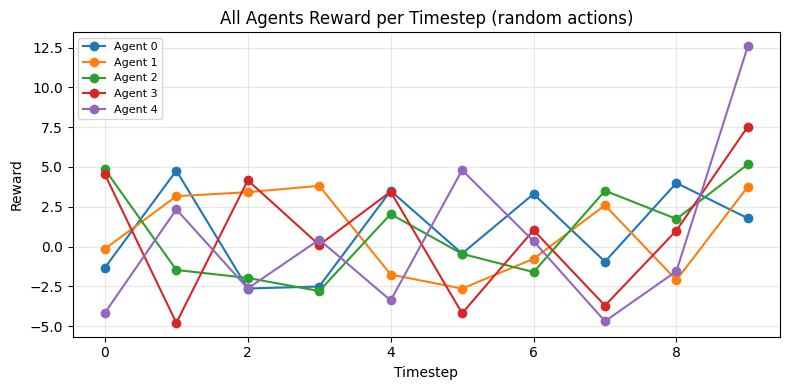

In [148]:
import matplotlib.pyplot as plt

env = TradingEnv()
state = env.reset()
done = False

i = 0
timestep_rewards = []   # collect rewards of all agents at each timestep

while not done:
    actions = np.random.uniform(-1, 1, size=env.N)  # random actions for testing
    next_state, rewards, done = env.step(actions)
    print(f"Next state: {i}", next_state)
    print("Rewards:", rewards)
    print("Done:", done)
    timestep_rewards.append(rewards.copy())   # shape (N,) per timestep
    i += 1

timestep_rewards = np.array(timestep_rewards)  # (M, N)

# Plot: reward of all agents across timesteps
plt.figure(figsize=(8, 4))
for agent_i in range(env.N):
    plt.plot(timestep_rewards[:, agent_i], marker='o', linewidth=1.5,
             label=f"Agent {agent_i}")
plt.title("All Agents Reward per Timestep (random actions)")
plt.xlabel("Timestep")
plt.ylabel("Reward")
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("all_agents_rewards.png", dpi=150)
plt.show()

## Testing Price dynamic in the absence of agents

Var(S_T)  = 0.000496
Expected  = 0.000500
Ratio     = 0.993


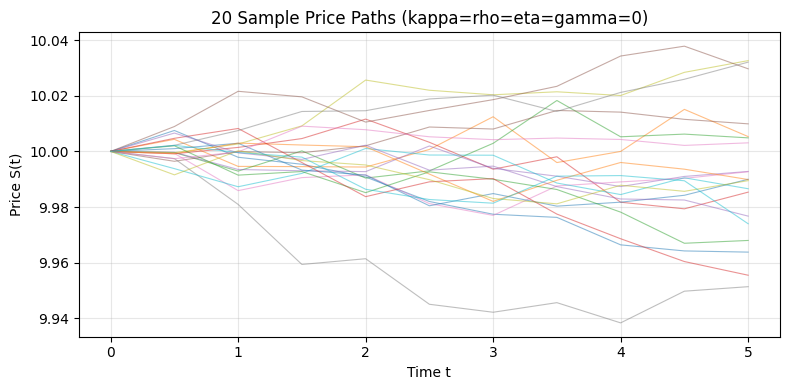

In [122]:
# Disable all interactions — pure Brownian motion
env.kappa = 0.0
env.rho   = 0.0
env.eta   = 0.0
env.gamma = 0.0

final_prices = []
sample_paths = []          # store a few trajectories for the path plot
N_PATHS       = 10000
N_SAMPLE_PLOT = 20         # number of trajectories to display

for ep in range(N_PATHS):
    env.reset()
    path = [env.S]         # record initial price
    for _ in range(env.M):
        env.step(np.zeros(env.N))
        path.append(env.S)
    final_prices.append(env.S)
    if ep < N_SAMPLE_PLOT:
        sample_paths.append(path)

var      = np.var(final_prices)
expected = env.sigma**2 * env.T   # = 0.01^2 * 5 = 0.0005

print(f"Var(S_T)  = {var:.6f}")
print(f"Expected  = {expected:.6f}")
print(f"Ratio     = {var/expected:.3f}")  # should be between 0.95 and 1.05

# Plot: sample Brownian motion paths
timesteps = np.linspace(0, env.T, env.M + 1)

plt.figure(figsize=(8, 4))
for path in sample_paths:
    plt.plot(timesteps, path, alpha=0.5, linewidth=0.8)
plt.title(f"{N_SAMPLE_PLOT} Sample Price Paths (kappa=rho=eta=gamma=0)")
plt.xlabel("Time t")
plt.ylabel("Price S(t)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("brownian_paths.png", dpi=150)
plt.show()

# ReplayBuffer construction for model training

In [91]:
from collections import deque
import random
import numpy as np


class ReplayBuffer:

    def __init__(self, max_size=100_000):
        self.buffer = deque(maxlen=max_size)

    def add(self, state, action, reward, next_state, done, inv=None):
        self.buffer.append((state, action, reward, next_state, done, inv))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, min(batch_size, len(self.buffer)))

        states, actions, rewards, next_states, dones, invs = zip(*batch)

        states = np.array(states)
        actions = np.array(actions)
        rewards = np.array(rewards)
        next_states = np.array(next_states)
        dones = np.array(dones)

        # Cas test simple (sans inv)
        if invs[0] is None:
            return states, actions, rewards, next_states, dones

        # Cas training Nash-DQN
        invs = np.array(invs)
        return states, actions, rewards, next_states, dones, invs

    def __len__(self):
        return len(self.buffer)

## ReplayBuffer testing

In [92]:

buf = ReplayBuffer(max_size=5)  # petit buffer pour tester l'éviction

# Remplis au-delà de max_size — les plus vieux doivent disparaître
for i in range(7):
    buf.add(np.zeros(4), np.zeros(2), np.zeros(2), np.zeros(4), False)

assert len(buf) == 5, "Buffer should evict old entries"

# Test sample shapes
states, actions, rewards, next_states, dones = buf.sample(3)
assert states.shape      == (3, 4), f"Got {states.shape}"
assert actions.shape     == (3, 2), f"Got {actions.shape}"
assert rewards.shape     == (3, 2), f"Got {rewards.shape}"
assert next_states.shape == (3, 4), f"Got {next_states.shape}"
assert dones.shape       == (3,),   f"Got {dones.shape}"

# Test sample quand buffer < batch_size
buf2 = ReplayBuffer()
buf2.add(np.zeros(4), np.zeros(2), np.zeros(2), np.zeros(4), False)
states, _, _, _, _ = buf2.sample(100)
assert states.shape == (1, 4), "Should sample everything when buffer < batch_size"

print("All buffer tests passed.")

All buffer tests passed.


# Model Construction

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import Tuple

def _mlp(sizes: list, activate_last: bool = False) -> nn.Sequential:
    """
    Builds a fully-connected MLP with SiLU activations between layers.

    Args:
        sizes         : list of layer widths e.g. [4, 32, 32, 1]
        activate_last : if True, adds SiLU after the last layer too

    Example:
        _mlp([4, 32, 32, 1])
        -> Linear(4,32) + SiLU + Linear(32,32) + SiLU + Linear(32,1)
    """
    layers = []
    for i in range(len(sizes) - 1):
        layers.append(nn.Linear(sizes[i], sizes[i + 1]))
        is_last = (i == len(sizes) - 2)
        if not is_last or activate_last:
            layers.append(nn.SiLU())
    return nn.Sequential(*layers)

# Permutation Invariant Layer

class PermutationInvariantLayer(nn.Module):
    """
    Implements equation (4.10) from the paper:

        f_inv(z) = sigma( sum_j phi(z_j) )

    phi is applied independently to each agent's features (shared weights).
    The SUM over agents makes the output invariant to any agent relabelling.
    sigma then transforms the aggregate.

    Paper Section 6.2: phi has 3 hidden layers x 20 nodes, SiLU.

    Args:
        d_in     : feature size per agent   (1 = scalar inventory)
        d_hidden : hidden width of phi      (20 in paper)
        d_out    : output dimension         (32 in paper)
        n_agents : N                        (2)
    """

    def __init__(self, d_in: int = 1, d_hidden: int = 20,
                 d_out: int = 32, n_agents: int = 5):
        super().__init__()
        self.n_agents = n_agents
        self.phi = _mlp(
            [d_in, d_hidden, d_hidden, d_hidden],
            activate_last=True
        )
        self.sigma = _mlp([d_hidden, d_out], activate_last=True)

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        """
        Args:
            z   : (B, N, d_in)   one feature vector per agent

        Returns:
            out : (B, d_out)     permutation-invariant aggregate
        """
        phi_out = self.phi(z)
        agg     = phi_out.sum(dim=1)
        return self.sigma(agg)


# Value Net

class ValueNet(nn.Module):
    """
    Approximates the value function V_i(x).

    Paper Section 6.2: 4 hidden layers x 32 nodes, SiLU.
    Under identical preferences + label invariance (Section 4.1),
    V_i is the same for all agents -> single shared scalar output.

    Args:
        d_state : state dimension  (4)
        hidden  : hidden width     (32)
    """

    def __init__(self, d_state: int = 4, hidden: int = 32):
        super().__init__()
        self.net = _mlp([d_state, hidden, hidden, hidden, hidden, 1])

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x  : (B, 4)

        Returns:
            V  : (B, 1)
        """
        return self.net(x)


# Advantage Network    A(x; u)


class AdvantageNet(nn.Module):
    """
    Outputs the parameters (mu, P11, P12, P22, psi) of the locally
    linear-quadratic advantage function.

    For N=2, scalar actions, equation (4.9) specialises to:

        A_i(x; u_i, u_j)
            = - P11_i * (u_i - mu_i)^2
              - P12_i * (u_i - mu_i) * (u_j - mu_j)
              - P22_i * (u_j - mu_j)^2
              + psi_i * (u_j - mu_j)

    Network outputs per agent: (mu_i, L11_i, P12_i, P22_i, psi_i)
    where P11_i = L11_i^2 + eps  (scalar Cholesky, always > 0)

    Architecture (Section 6.2):
        perm-inv layer (3x20)  ->  concatenated with state
        ->  main network (4x32, SiLU)
        ->  output head (5 scalars)

    Args:
        d_state     : full state dimension    (4)
        n_agents    : N                       (2)
        hidden      : main network width      (32)
        perm_hidden : phi hidden width        (20)
        perm_out    : perm-inv output dim     (32)
    """

    def __init__(self, d_state: int = 4, n_agents: int = 5,
                 hidden: int = 32, perm_hidden: int = 20, perm_out: int = 32):
        super().__init__()
        self.n_agents = n_agents
        self.perm_inv = PermutationInvariantLayer(
            d_in=1, d_hidden=perm_hidden,
            d_out=perm_out, n_agents=n_agents
        )
        self.main_net = _mlp(
            [d_state + perm_out, hidden, hidden, hidden, hidden],
            activate_last=True
        )
        self.head = nn.Linear(hidden, 5)

    def forward(
        self,
        x: torch.Tensor,
        inventories: torch.Tensor
    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor,
               torch.Tensor, torch.Tensor]:
        """
        Args:
            x           : (B, 4)   state  (S_t, t, total_flow, Y_t)
            inventories : (B, N)   per-agent inventories q_{i,t}

        Returns (all shape (B, N)):
            mu   : Nash policy mu_i(x)       -- equilibrium action
            P11  : own quadratic coeff       > 0 always
            P12  : cross-action coeff
            P22  : opponent quadratic coeff
            psi  : opponent linear coeff     (target of L1 regulariser)
        """
        B = x.shape[0]

        # Step 1: permutation-invariant path
        inv_feats = inventories.unsqueeze(-1)
        perm_out  = self.perm_inv(inv_feats)

        # Step 2: main network
        # Concatenate full state with perm-inv output
        combined = torch.cat([x, perm_out], dim=-1)
        h        = self.main_net(combined)
        raw      = self.head(h)

        # Step 3: unpack the 5 parameters
        mu_raw  = raw[:, 0]
        L11_raw = raw[:, 1]
        P12_raw = raw[:, 2]
        P22_raw = raw[:, 3]
        psi_raw = raw[:, 4]

        # Step 4: enforce P11 > 0 via scalar Cholesky
        P11 = L11_raw.pow(2) + 1e-6

        # Step 5: expand to (B, N)
        def expand(t: torch.Tensor) -> torch.Tensor:
            return t.unsqueeze(1).expand(B, self.n_agents).contiguous()

        return (expand(mu_raw),  expand(P11),
                expand(P12_raw), expand(P22_raw), expand(psi_raw))


# Compute_advantage() 

def compute_advantage(mu, P11, P12, P22, psi, u):
    """
    Label-invariant advantage for N agents, scalar actions (eq. 4.9/4.12).

    A_i = -P11_i*(u_i-mu_i)^2
          -P12_i*(u_i-mu_i)*sum_{j≠i}(u_j-mu_j)
          -P22_i*sum_{j≠i}(u_j-mu_j)^2
          +psi_i*sum_{j≠i}(u_j-mu_j)
    """
    delta     = u - mu                           # (B, N)
    delta_sum = delta.sum(dim=1, keepdim=True)   # (B, 1) — sum over all agents

    # sum_{j≠i}(u_j - mu_j) = total_sum - own_delta
    delta_others = delta_sum - delta             # (B, N)

    A = (- P11 * delta ** 2
         - P12 * delta * delta_others
         - P22 * delta_others ** 2
         + psi * delta_others)

    return A   # (B, N)
# NashDQN: full model

class NashDQN(nn.Module):
    """
    Complete Nash-DQN model.

    Q_i(x; u) = V_i(x) + A_i(x; u)    [eq. 4.3]
    u*_i(x)   = mu_i^theta(x)          [eq. 4.6]  <- analytic Nash action

    The Nash action is computed analytically from the network output.
    No inner optimisation loop needed -- that is the key advantage of
    the quadratic structure.

    Args:
        d_state     : state dimension  (4)
        n_agents    : N                (2)
        hidden      : hidden width     (32)
        perm_hidden : phi width        (20)
        perm_out    : perm-inv output  (32)
    """

    def __init__(self, d_state: int = 4, n_agents: int = 2,
                 hidden: int = 32, perm_hidden: int = 20, perm_out: int = 32):
        super().__init__()
        self.n_agents = n_agents

        self.value_net = ValueNet(d_state=d_state, hidden=hidden)

        self.adv_net = AdvantageNet(
            d_state=d_state, n_agents=n_agents,
            hidden=hidden, perm_hidden=perm_hidden, perm_out=perm_out
        )

    def forward(
        self,
        x:           torch.Tensor,
        inventories: torch.Tensor,
        u:           torch.Tensor
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Computes Q_i(x; u) = V_i(x) + A_i(x; u).

        Args:
            x           : (B, 4)
            inventories : (B, 2)
            u           : (B, 2)  joint actions [u_1, u_2]

        Returns:
            Q   : (B, 2)  Q-value per agent
            psi : (B, 2)  psi values needed for L1 regulariser in loss
        """
        # V(x) expanded to match both agents
        V = self.value_net(x).expand(-1, self.n_agents)

        # Advantage parameters from network
        mu, P11, P12, P22, psi = self.adv_net(x, inventories)

        # Advantage value
        A = compute_advantage(mu, P11, P12, P22, psi, u)

        return V + A, psi

    def nash_action(
        self,
        x:           torch.Tensor,
        inventories: torch.Tensor
    ) -> torch.Tensor:
        """
        Returns u*(x) = mu^theta(x).
        Analytic closed form -- no inner loop.    [eq. 4.6]

        Args:
            x           : (B, 4)
            inventories : (B, 2)

        Returns:
            mu : (B, 2)  Nash equilibrium actions for both agents
        """
        mu, _, _, _, _ = self.adv_net(x, inventories)
        return mu

## Model Testing

UNIT TESTS — Student D, Week 2

-- Test 1: Replay buffer shapes --
[OK] Buffer size : 1000
[OK] states      : (16, 4)
[OK] actions     : (16, 2)
[OK] rewards     : (16, 1)
[OK] next_states : (16, 4)
[OK] dones       : (16,)

-- Test 2: ValueNet output shape --
[OK] ValueNet output : torch.Size([16, 1])

-- Test 3: AdvantageNet output shapes --
[OK] mu  : torch.Size([16, 2])
[OK] P11 : torch.Size([16, 2])
[OK] P12 : torch.Size([16, 2])
[OK] P22 : torch.Size([16, 2])
[OK] psi : torch.Size([16, 2])

-- Test 4: NashDQN forward shapes --
[OK] Q shape   : torch.Size([16, 2])
[OK] psi shape : torch.Size([16, 2])

-- Test 5: Nash action shape --
[OK] Nash action shape : torch.Size([16, 2])

-- Test 6: Advantage = 0 at Nash --
[OK] A at Nash : 0.00e+00  (must be 0.00e+00)

-- Test 7: P11 > 0 everywhere --
[OK] P11 min : 4.45e-05  (must be > 0)

-- Test 8: Q at Nash == V --
[OK] |Q_nash - V| max : 0.00e+00  (must be ~0)

-- Test 9: Permutation invariance --
[OK] Perm-inv output shape : torch.Siz

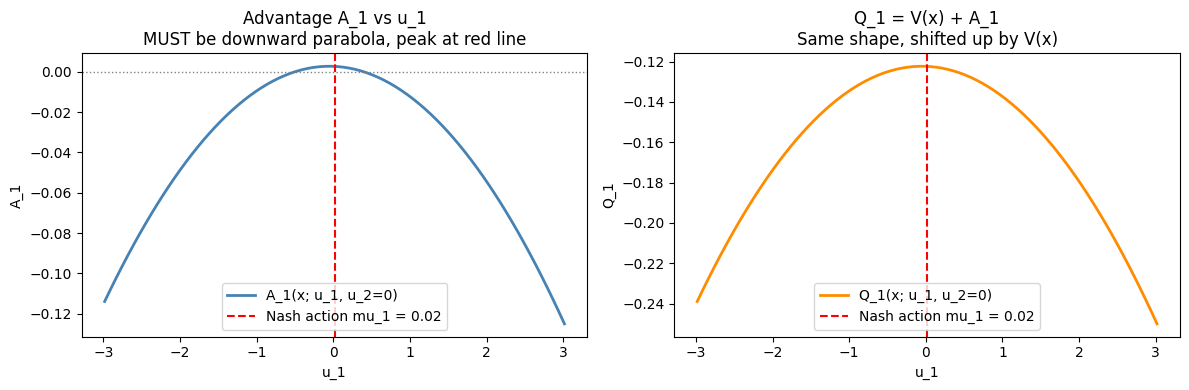

In [93]:
import torch
import numpy as np

# =============================================================================
# SETUP
# =============================================================================

torch.manual_seed(42)
B, N = 16, 2

print("=" * 55)
print("UNIT TESTS — Student D, Week 2")
print("=" * 55)

# Create all components
value_net  = ValueNet(d_state=4, hidden=32)
adv_net    = AdvantageNet(d_state=4, n_agents=2, hidden=32,
                          perm_hidden=20, perm_out=32)
perm_layer = PermutationInvariantLayer(d_in=1, d_hidden=20,
                                       d_out=32, n_agents=2)
model      = NashDQN(d_state=4, n_agents=2, hidden=32,
                     perm_hidden=20, perm_out=32)

# Dummy torch tensors for network tests
x   = torch.randn(B, 4)
inv = torch.rand(B, N).abs()
u   = torch.randn(B, N)


# =============================================================================
# TEST 1 — Replay buffer: store + sample + shape checks
# =============================================================================

print("\n-- Test 1: Replay buffer shapes --")

buf = ReplayBuffer(max_size=100_000)

# Fill buffer with 1000 random transitions
for step in range(1000):
    state      = np.random.randn(4).astype(np.float32)   # (4,)
    action     = np.random.randn(2).astype(np.float32)   # (2,)
    reward     = np.random.randn(1).astype(np.float32)   # (1,)
    next_state = np.random.randn(4).astype(np.float32)   # (4,)
    done       = False

    buf.add(state, action, reward, next_state, done)      # uses .add()

assert len(buf) == 1000
print(f"[OK] Buffer size : {len(buf)}")

# .sample() returns plain numpy arrays — NOT namedtuples
states, actions, rewards, next_states, dones = buf.sample(B)

# Check shapes
assert states.shape      == (B, 4), f"states shape wrong: {states.shape}"
assert actions.shape     == (B, 2), f"actions shape wrong: {actions.shape}"
assert rewards.shape     == (B, 1), f"rewards shape wrong: {rewards.shape}"
assert next_states.shape == (B, 4), f"next_states shape wrong: {next_states.shape}"
assert dones.shape       == (B,),   f"dones shape wrong: {dones.shape}"

print(f"[OK] states      : {states.shape}")       # (B, 4)
print(f"[OK] actions     : {actions.shape}")      # (B, 2)
print(f"[OK] rewards     : {rewards.shape}")      # (B, 1)
print(f"[OK] next_states : {next_states.shape}")  # (B, 4)
print(f"[OK] dones       : {dones.shape}")        # (B,)

# Convert to torch tensors for network tests below
x_batch      = torch.tensor(states,      dtype=torch.float32)   # (B, 4)
u_batch      = torch.tensor(actions,     dtype=torch.float32)   # (B, 2)
r_batch      = torch.tensor(rewards,     dtype=torch.float32)   # (B, 1)
xn_batch     = torch.tensor(next_states, dtype=torch.float32)   # (B, 4)
done_batch   = torch.tensor(dones,       dtype=torch.float32)   # (B,)
inv_batch    = torch.rand(B, N)                                  # (B, 2) dummy


# =============================================================================
# TEST 2 — ValueNet output shape
# =============================================================================

print("\n-- Test 2: ValueNet output shape --")

V_out = value_net(x_batch)
assert V_out.shape == (B, 1), f"ValueNet shape wrong: {V_out.shape}"
print(f"[OK] ValueNet output : {V_out.shape}")   # (B, 1)


# =============================================================================
# TEST 3 — AdvantageNet output shapes
# =============================================================================

print("\n-- Test 3: AdvantageNet output shapes --")

mu, P11, P12, P22, psi = adv_net(x_batch, inv_batch)

assert mu.shape  == (B, N), f"mu  shape wrong: {mu.shape}"
assert P11.shape == (B, N), f"P11 shape wrong: {P11.shape}"
assert P12.shape == (B, N), f"P12 shape wrong: {P12.shape}"
assert P22.shape == (B, N), f"P22 shape wrong: {P22.shape}"
assert psi.shape == (B, N), f"psi shape wrong: {psi.shape}"

print(f"[OK] mu  : {mu.shape}")    # (B, 2)
print(f"[OK] P11 : {P11.shape}")   # (B, 2)
print(f"[OK] P12 : {P12.shape}")   # (B, 2)
print(f"[OK] P22 : {P22.shape}")   # (B, 2)
print(f"[OK] psi : {psi.shape}")   # (B, 2)


# =============================================================================
# TEST 4 — NashDQN forward output shapes
# =============================================================================

print("\n-- Test 4: NashDQN forward shapes --")

Q, psi_out = model(x_batch, inv_batch, u_batch)

assert Q.shape       == (B, N), f"Q shape wrong: {Q.shape}"
assert psi_out.shape == (B, N), f"psi shape wrong: {psi_out.shape}"

print(f"[OK] Q shape   : {Q.shape}")        # (B, 2)
print(f"[OK] psi shape : {psi_out.shape}")  # (B, 2)


# =============================================================================
# TEST 5 — Nash action shape
# =============================================================================

print("\n-- Test 5: Nash action shape --")

u_nash = model.nash_action(x_batch, inv_batch)

assert u_nash.shape == (B, N), f"Nash action shape wrong: {u_nash.shape}"
print(f"[OK] Nash action shape : {u_nash.shape}")   # (B, 2)


# =============================================================================
# TEST 6 — Advantage = 0 at Nash point    [eq. 4.6]
# =============================================================================

print("\n-- Test 6: Advantage = 0 at Nash --")

# When u = mu exactly, every delta = 0
# so every term in compute_advantage is zero
A_at_nash = compute_advantage(mu, P11, P12, P22, psi, mu)
error = A_at_nash.abs().max().item()

assert error < 1e-5, f"Advantage at Nash should be 0! error={error}"
print(f"[OK] A at Nash : {error:.2e}  (must be 0.00e+00)")


# =============================================================================
# TEST 7 — P11 > 0 everywhere    [Cholesky guarantee]
# =============================================================================

print("\n-- Test 7: P11 > 0 everywhere --")

assert P11.min().item() > 0, f"P11 not positive! min={P11.min().item()}"
print(f"[OK] P11 min : {P11.min().item():.2e}  (must be > 0)")


# =============================================================================
# TEST 8 — Q at Nash == V    [eq. 4.3 + 4.6]
# =============================================================================

print("\n-- Test 8: Q at Nash == V --")

# At u* = mu, advantage A = 0, so Q(x, u*) = V(x) + 0 = V(x)
Q_at_nash, _ = model(x_batch, inv_batch, u_nash)
V_expanded   = model.value_net(x_batch).expand(-1, N)
diff_QV      = (Q_at_nash - V_expanded).abs().max().item()

assert diff_QV < 1e-5, f"Q at Nash should equal V! diff={diff_QV}"
print(f"[OK] |Q_nash - V| max : {diff_QV:.2e}  (must be ~0)")


# =============================================================================
# TEST 9 — Permutation invariance    [eq. 4.10]
# =============================================================================

print("\n-- Test 9: Permutation invariance --")

inv_feats      = inv_batch.unsqueeze(-1)         # (B, N, 1)
inv_feats_perm = inv_feats[:, [1, 0], :]         # swap agent 0 and 1

out_orig = perm_layer(inv_feats)                 # (B, 32)
out_perm = perm_layer(inv_feats_perm)            # (B, 32)

diff_perm = (out_orig - out_perm).abs().max().item()

assert diff_perm < 1e-5, f"Permutation invariance failed! diff={diff_perm}"
print(f"[OK] Perm-inv output shape : {out_orig.shape}")     # (B, 32)
print(f"[OK] Label-invariance diff : {diff_perm:.2e}  (must be ~0)")


# =============================================================================
# TEST 10 — Nash action permutation invariance
# =============================================================================

print("\n-- Test 10: Nash action permutation invariance --")

inv_perm    = inv_batch[:, [1, 0]]               # swap agents
u_nash_perm = model.nash_action(x_batch, inv_perm)
diff_nash   = (u_nash - u_nash_perm).abs().max().item()

print(f"[OK] Nash perm diff : {diff_nash:.2e}  (must be ~0 under label invariance)")

# ── Test 11: concavity — plot A vs u_1  (not Q) ──────────────────────
print("\n-- Test 11: Concavity of A in u_1 --")

try:
    import matplotlib.pyplot as plt

    x_s   = x_batch[0:1]     # (1, 4)
    inv_s = inv_batch[0:1]    # (1, 2)

    # Get network parameters for this single sample
    mu_s, P11_s, P12_s, P22_s, psi_s = model.adv_net(x_s, inv_s)
    mu1 = mu_s[0, 0].item()

    # Sweep u_1 while u_2 is fixed at 0
    u1_values = torch.linspace(mu1 - 3, mu1 + 3, 80)
    A1_values = []
    Q1_values = []

    for u1 in u1_values:
        u_test = torch.tensor([[u1.item(), 0.0]])

        # Advantage alone — this MUST be a downward parabola
        A_val = compute_advantage(mu_s, P11_s, P12_s, P22_s, psi_s, u_test)
        A1_values.append(A_val[0, 0].item())

        # Q = V + A — same shape but shifted by V(x) constant
        Q_val, _ = model(x_s, inv_s, u_test)
        Q1_values.append(Q_val[0, 0].item())

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Plot A — must be downward parabola peaking at mu1
    ax1.plot(u1_values.numpy(), A1_values,
             color="steelblue", linewidth=2, label="A_1(x; u_1, u_2=0)")
    ax1.axvline(x=mu1, color="red", linestyle="--",
                label=f"Nash action mu_1 = {mu1:.2f}")
    ax1.axhline(y=0, color="gray", linestyle=":", linewidth=1)
    ax1.set_xlabel("u_1")
    ax1.set_ylabel("A_1")
    ax1.set_title("Advantage A_1 vs u_1\nMUST be downward parabola, peak at red line")
    ax1.legend()

    # Plot Q — same shape, shifted by V(x)
    ax2.plot(u1_values.numpy(), Q1_values,
             color="darkorange", linewidth=2, label="Q_1(x; u_1, u_2=0)")
    ax2.axvline(x=mu1, color="red", linestyle="--",
                label=f"Nash action mu_1 = {mu1:.2f}")
    ax2.set_xlabel("u_1")
    ax2.set_ylabel("Q_1")
    ax2.set_title("Q_1 = V(x) + A_1\nSame shape, shifted up by V(x)")
    ax2.legend()

    plt.tight_layout()
    plt.savefig("concavity_check.png", dpi=120)
    print("[OK] Plot saved -> concavity_check.png")
    print(f"     Nash action mu_1 = {mu1:.4f}")
    print(f"     A at Nash        = {A1_values[40]:.6f}  (must be ~0)")
    print("     Left plot MUST be a downward parabola peaking at red line")

except ImportError:
    print("[SKIP] matplotlib not installed")


# =============================================================================
# SUMMARY
# =============================================================================

print("\n" + "=" * 55)
print("All Week 2 tests passed.")
print("=" * 55)
print("""
What each test proved:
  Test 1  : Buffer .add() works, .sample() returns correct numpy shapes
  Test 2  : ValueNet  (B,4) -> (B,1)
  Test 3  : AdvantageNet returns 5 tensors all (B,2)
  Test 4  : NashDQN forward returns Q (B,2) and psi (B,2)
  Test 5  : Nash action shape is (B,2)
  Test 6  : A = 0 at Nash  [eq. 4.6 verified]
  Test 7  : P11 > 0 everywhere  [Cholesky working]
  Test 8  : Q(x, u*) = V(x)  [eq. 4.3 + 4.6 verified]
  Test 9  : Perm-inv layer truly invariant to agent order
  Test 10 : Nash action invariant to agent relabelling
  Test 11 : Q is concave in u_i  [plot saved]
""")

# Time Weighted Average Price baseline

In [149]:

class TWAPAgent:
    """
    Time Weighted Average Price baseline.
    Sells inventory uniformly across all time steps.
    nu_i = q_{i,0} / T  (constant selling rate)
    """
    
    def __init__(self, env):
        self.rate = env.inv0[0] / env.T   # = 1.0 / 5.0 = 0.2
    
    def act(self, state):
        # ignore state completely always same action
        return -self.rate   # negative = selling


## Testing TWAP

In [150]:
env = TradingEnv()
env.reset()
twap = TWAPAgent(env)
N_EPISODES = 10000

rewards_twap = []

for _ in range(N_EPISODES):
    state    = env.reset()
    ep_reward = np.zeros(env.N)
    
    for _ in range(env.M):
        actions = np.array([twap.act(state)] * env.N)
        state, rewards, done = env.step(actions)
        ep_reward += rewards
    
    rewards_twap.append(ep_reward.mean())

print(f"TWAP mean reward : {np.mean(rewards_twap):.4f}")
print(f"TWAP std         : {np.std(rewards_twap):.4f}")

TWAP mean reward : 9.6855
TWAP std         : 0.0102


# Agents Training

In [ ]:
import torch
import numpy as np
import torch.optim as optim
import torch.nn.functional as F

# ==============================================================================
# TRAINING LOOP (IMPROVED NASH VERSION)
# ==============================================================================

def train(env, model,
          episodes=5000,
          batch_size=64,
          gamma=0.95,
          beta=5.0,
          lr=3e-4,
          sigma_0=0.3,
          sigma_decay=0.999,
          sigma_min=0.05):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    target_model = NashDQN(n_agents=env.N).to(device)
    target_model.load_state_dict(model.state_dict())
    target_model.eval()

    optimizer_V = optim.Adam(model.value_net.parameters(), lr=lr)
    optimizer_A = optim.Adam(model.adv_net.parameters(), lr=lr)

    buffer = ReplayBuffer()

    episode_rewards = []
    step_losses = []

    sigma = sigma_0
    tau = 0.002  # stable soft update

    # INIT
    for m in model.modules():
        if isinstance(m, torch.nn.Linear):
            torch.nn.init.xavier_uniform_(m.weight)
            torch.nn.init.zeros_(m.bias)

    for ep in range(episodes):

        state = env.reset()
        ep_reward = np.zeros(env.N)

        for _ in range(env.M):

            x = torch.FloatTensor(state).unsqueeze(0).to(device)
            inv = torch.FloatTensor(env.inv).unsqueeze(0).to(device)

            with torch.no_grad():
                action = model.nash_action(x, inv).cpu().numpy()[0]

            # zero-sum exploration noise 
            noise = np.random.normal(0.0, sigma, size=env.N)
            noise -= noise.mean()

            action = np.clip(action + noise, -2.0, 2.0)

            next_state, reward, done = env.step(action)

            buffer.add(state, action, reward, next_state, done, inv=env.inv.copy())

            state = next_state
            ep_reward += reward

            if len(buffer) < batch_size:
                continue

            states, actions, rewards, next_states, dones, invs = buffer.sample(batch_size)

            s  = torch.FloatTensor(states).to(device)
            a  = torch.FloatTensor(actions).to(device)
            r  = torch.FloatTensor(rewards).to(device) / 10.0
            s2 = torch.FloatTensor(next_states).to(device)
            d  = torch.FloatTensor(dones).to(device)

            #inv = torch.zeros(batch_size, env.N).to(device)
            
            inv  = torch.FloatTensor(invs).to(device)
            inv2 = torch.FloatTensor(invs).to(device)  # approximation OK ici

            # ================= TARGET =================
            with torch.no_grad():
                next_actions = model.nash_action(s2, inv2)
                Q_next, _ = target_model(s2, inv2, next_actions)

                y = r + gamma * Q_next * (1.0 - d.unsqueeze(1))

            # ================= VALUE =================
            Q_pred, _ = model(s, inv2, a)
            loss_V = F.smooth_l1_loss(Q_pred, y)

            optimizer_V.zero_grad()
            loss_V.backward()
            torch.nn.utils.clip_grad_norm_(model.value_net.parameters(), 0.5)
            optimizer_V.step()

            # ================= ADV =================
            Q_pred, psi = model(s, inv2, a)

            loss_A = beta * psi.abs().mean()

            optimizer_A.zero_grad()
            loss_A.backward()
            torch.nn.utils.clip_grad_norm_(model.adv_net.parameters(), 0.5)
            optimizer_A.step()

            step_losses.append(loss_A.item())

            # ================= SOFT UPDATE =================
            for tp, p in zip(target_model.parameters(), model.parameters()):
                tp.data.copy_(tau * p.data + (1 - tau) * tp.data)

        episode_rewards.append(ep_reward.mean())

        sigma = max(sigma_min, sigma * sigma_decay)

        if ep % 50 == 0:
            print(f"ep={ep} | reward={ep_reward.mean():+.4f} | sigma={sigma:.4f}")

    return model, step_losses, episode_rewards

In [174]:
import numpy as np

class TradingEnv:
    """
    Market simulator for the N-agent optimal execution problem.
    Implements the stochastic game from Casgrain, Ning & Jaimungal (2022).

    State vector: x_t = [S_t/S_0, t/T, total_sold/total_inv0, Y_t]
    """

    def __init__(self):
        # --- Market parameters (Table 1 of paper) ---
        self.kappa = 0.1    # mean-reversion speed of price toward theta
        self.theta = 10.0   # long-run mean price level
        self.sigma = 0.01   # price volatility (diffusion coefficient)
        self.gamma = 0.02   # transient impact scale (NOT the discount factor)
        self.rho = 0.5      # transient impact decay rate
        self.eta = 0.05     # permanent price impact coefficient
        self.b1 = 0.001     # linear transaction cost coefficient
        self.b2 = 2         # terminal inventory penalty coefficient
        self.b3 = 1         # running inventory penalty (zero in Table 1)

        # --- Simulation settings ---
        self.N = 5                  # number of agents
        self.T = 5.0                # time horizon in hours
        self.M = 10                 # number of decision steps
        self.dt = self.T / self.M   # time step size = 0.5


    def reset(self):
        """
        Reset all environment variables for a new episode.
        Must be called before every training episode.

        Returns:
            np.array shape (4,): initial state vector x_0
        """
        self.S = 10.0                    # initial mid-price
        self.Y = 0.0                     # transient impact starts at zero
        self.t = 0.0                     # current time
        self.inv = np.ones(self.N)       # each agent starts with inventory = 1
        self.inv0 = self.inv.copy()      # store initial inventory for _get_state()

        return self._get_state()


    def step(self, actions):
        """
        Advance the environment by one timestep given all agents' actions.

        Update order: reward -> inventory -> time -> Y -> S
        Reward must use S_t BEFORE the price update (reward is for trading at current price).

        Args:
            actions: array-like shape (N,) — trading rates nu_i
                     positive = buying, negative = selling

        Returns:
            next_state : np.array shape (4,)
            rewards    : np.array shape (N,)
            done       : bool
        """
        nu = np.array(actions)
        nu_bar = np.sum(nu)         # aggregate flow — drives price impact 

        # Step 1 — Reward uses current S and current inv (before any updates)
        rewards = self._compute_reward(nu)

        # Step 2 — Update inventory: q_{i,t+dt} = q_{i,t} + nu_i * dt  
        self.inv = self.inv + nu * self.dt

        # Step 3 — Advance time
        self.t += self.dt

        # Step 4 — Update transient impact Y 
        Y_old = self.Y
        h = np.sign(nu_bar) * np.sqrt(np.abs(nu_bar) + 1e-8)  # sqrt impact, safe near 0
        self.Y = (1 - self.rho * self.dt) * self.Y + self.gamma * h * self.dt
        dY = self.Y - Y_old     # change in Y for this step, needed for S update

        # Step 5 — Update mid-price S — Euler-Maruyama discretisation
        # dS = [kappa*(theta - S) + eta*nu_bar]*dt + dY + sigma*sqrt(dt)*epsilon
        drift = self.kappa * (self.theta - self.S) + self.eta * nu_bar
        noise = self.sigma * np.sqrt(self.dt) * np.random.randn()
        self.S = self.S + drift * self.dt + dY + noise

        done = self.t >= self.T - 1e-9
        return self._get_state(), rewards, done


    def _compute_reward(self, nu):
        """
        Per-agent reward for the current timestep.

        Three components:
          (i)   Trading cost:          -nu_i * (S + b1*nu_i) * dt
          (ii)  Running urgency:       -b3 * q_i^2 * dt          (zero when b3=0)
          (iii) Terminal liquidation:   q_{i,T} * (S_T - b2*q_{i,T})  — last step only

        The terminal term uses q_{i,T} = inv[i] + nu[i]*dt (inventory AFTER this trade).
        The terminal condition checks self.t against T-dt because self.t has not been
        advanced yet when this method is called.

        Args:
            nu: np.array shape (N,)

        Returns:
            rewards: np.array shape (N,)
        """
        rewards = np.zeros(self.N)

        is_terminal = self.t >= self.T - self.dt - 1e-9  # float-safe last-step check

        for i in range(self.N):
            trading_cost = -nu[i] * (self.S + self.b1 * nu[i]) * self.dt
            urgency_cost = -self.b3 * (self.inv[i] ** 2) * self.dt
            rewards[i] = trading_cost + urgency_cost

            if is_terminal:
                q_T = self.inv[i] + nu[i] * self.dt  # inventory after final trade
                terminal_gain = q_T * (self.S - self.b2 * q_T)
                rewards[i] += terminal_gain

        return rewards

    def _get_state(self):
        """
        Build the 4-dimensional state vector (eq. 20).

        Components:
          [0] S_t / S_0          — normalised price (S_0 = 10)
          [1] t / T              — fraction of horizon elapsed
          [2] total_sold / sum(inv0) — normalised aggregate inventory change
          [3] Y_t                — transient impact level (already small scale)

        Returns:
            np.array shape (4,), dtype float32
        """
        total_sold = np.sum(self.inv0 - self.inv)

        return np.array([
            self.S / 10.0,
            self.t / self.T,
            total_sold / np.sum(self.inv0),
            self.Y
        ], dtype=np.float32)

import torch
import numpy as np
import torch.optim as optim
import torch.nn.functional as F

# ==============================================================================
# TRAINING LOOP (IMPROVED NASH VERSION)
# ==============================================================================

def train(env, model,
          episodes=5000,
          batch_size=64,
          gamma=0.95,
          beta=5.0,
          lr=3e-4,
          sigma_0=0.3,
          sigma_decay=0.999,
          sigma_min=0.05):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    target_model = NashDQN(n_agents=env.N).to(device)
    target_model.load_state_dict(model.state_dict())
    target_model.eval()

    optimizer_V = optim.Adam(model.value_net.parameters(), lr=lr)
    optimizer_A = optim.Adam(model.adv_net.parameters(), lr=lr)

    buffer = ReplayBuffer()

    episode_rewards = []
    step_losses = []

    sigma = sigma_0
    tau = 0.002  # stable soft update

    # INIT
    for m in model.modules():
        if isinstance(m, torch.nn.Linear):
            torch.nn.init.xavier_uniform_(m.weight)
            torch.nn.init.zeros_(m.bias)

    for ep in range(episodes):

        state = env.reset()
        ep_reward = np.zeros(env.N)

        for _ in range(env.M):

            x = torch.FloatTensor(state).unsqueeze(0).to(device)
            inv = torch.FloatTensor(env.inv).unsqueeze(0).to(device)

            with torch.no_grad():
                action = model.nash_action(x, inv).cpu().numpy()[0]

            # zero-sum exploration noise 
            noise = np.random.normal(1, sigma, size=env.N)
            noise -= noise.mean()
            action = np.clip(action + noise, -2.0, 2.0)

            next_state, reward, done = env.step(action)

            buffer.add(state, action, reward, next_state, done, inv=env.inv.copy())

            state = next_state
            ep_reward += reward

            if len(buffer) < batch_size:
                continue

            states, actions, rewards, next_states, dones, invs = buffer.sample(batch_size)

            s  = torch.FloatTensor(states).to(device)
            a  = torch.FloatTensor(actions).to(device)
            r  = torch.FloatTensor(rewards).to(device) / 10.0
            s2 = torch.FloatTensor(next_states).to(device)
            d  = torch.FloatTensor(dones).to(device)

            
            inv  = torch.FloatTensor(invs).to(device)
            inv2 = torch.FloatTensor(invs).to(device)  

            # ================= TARGET =================
            with torch.no_grad():
                next_actions = model.nash_action(s2, inv2)
                Q_next, _ = target_model(s2, inv2, next_actions)

                y = r + gamma * Q_next * (1.0 - d.unsqueeze(1))

            # ================= VALUE =================
            Q_pred, _ = model(s, inv2, a)
            loss_V = F.smooth_l1_loss(Q_pred, y)

            optimizer_V.zero_grad()
            loss_V.backward()
            torch.nn.utils.clip_grad_norm_(model.value_net.parameters(), 0.5)
            optimizer_V.step()

            # ================= ADV =================
            Q_pred, psi = model(s, inv2, a)

            loss_A = beta * psi.abs().mean()

            optimizer_A.zero_grad()
            loss_A.backward()
            torch.nn.utils.clip_grad_norm_(model.adv_net.parameters(), 0.5)
            optimizer_A.step()

            step_losses.append(loss_A.item())

            # ================= SOFT UPDATE =================
            for tp, p in zip(target_model.parameters(), model.parameters()):
                tp.data.copy_(tau * p.data + (1 - tau) * tp.data)

        episode_rewards.append(ep_reward.mean())

        sigma = max(sigma_min, sigma * sigma_decay)

        if ep % 50 == 0:
            print(f"ep={ep} | reward={ep_reward.mean():+.4f} | sigma={sigma:.4f}", "Actions:", np.mean(np.abs(action)), "Inventories:", env.inv)

    return model, step_losses, episode_rewards

In [175]:
import matplotlib.pyplot as plt

env   = TradingEnv()
model = NashDQN(n_agents=env.N)

model, step_losses, episode_rewards = train(
    env=env,
    model=model,
    episodes=5000,
    batch_size=32,
    gamma=0.95,
    lr=3e-3
)

print("Training done")

ep=0 | reward=+2.4186 | sigma=0.2997 Actions: 0.2254239749628711 Inventories: [1.02439457 0.49500302 0.75368927 1.50785726 1.32421104]
ep=50 | reward=+2.6803 | sigma=0.2851 Actions: 0.23268702646039569 Inventories: [1.34161088 1.01661722 0.76725366 1.15546022 0.71654133]
ep=100 | reward=+2.5750 | sigma=0.2712 Actions: 0.2805542772324795 Inventories: [1.26203378 0.62293021 1.38114426 0.91724197 0.81488548]
ep=150 | reward=+2.2163 | sigma=0.2579 Actions: 0.20548518819492329 Inventories: [1.31314803 1.04339628 0.19670774 1.05678382 1.38884494]
ep=200 | reward=+1.9473 | sigma=0.2453 Actions: 0.2953084850903011 Inventories: [0.02911675 0.91782197 1.24983527 1.69723191 1.11031903]
ep=250 | reward=+2.7838 | sigma=0.2334 Actions: 0.05731018237420597 Inventories: [0.80837638 1.07957444 0.94524703 1.2990236  0.85892733]
ep=300 | reward=+2.5115 | sigma=0.2220 Actions: 0.11318735444245176 Inventories: [1.07229515 1.5159323  0.65892325 0.7822058  0.966526  ]
ep=350 | reward=+2.7608 | sigma=0.2112 A

KeyboardInterrupt: 

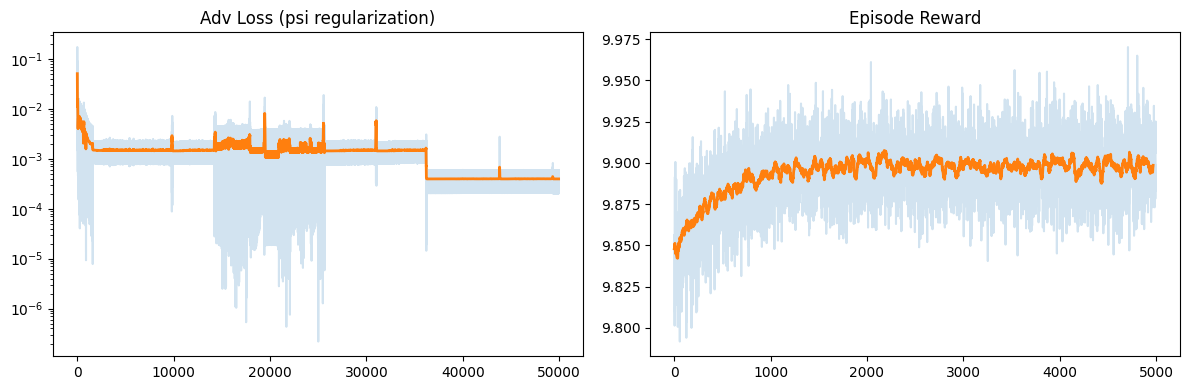

In [125]:
def smooth(x, w=30):
    if len(x) < w:
        return np.array(x)
    return np.convolve(x, np.ones(w)/w, mode="valid")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# LOSS
axes[0].plot(step_losses, alpha=0.2)
axes[0].plot(smooth(step_losses), linewidth=2)
axes[0].set_title("Adv Loss (psi regularization)")
axes[0].set_yscale("log")

# REWARD
axes[1].plot(episode_rewards, alpha=0.2)
axes[1].plot(smooth(episode_rewards), linewidth=2)
axes[1].set_title("Episode Reward")

plt.tight_layout()
plt.show()

NASH vs TWAP
Agent 0 | Nash=+9.9006 TWAP=+9.8605 Δ=+0.0400
Agent 1 | Nash=+9.9006 TWAP=+9.8605 Δ=+0.0400
Agent 2 | Nash=+9.9006 TWAP=+9.8605 Δ=+0.0400
Agent 3 | Nash=+9.9006 TWAP=+9.8605 Δ=+0.0400
Agent 4 | Nash=+9.9006 TWAP=+9.8605 Δ=+0.0400


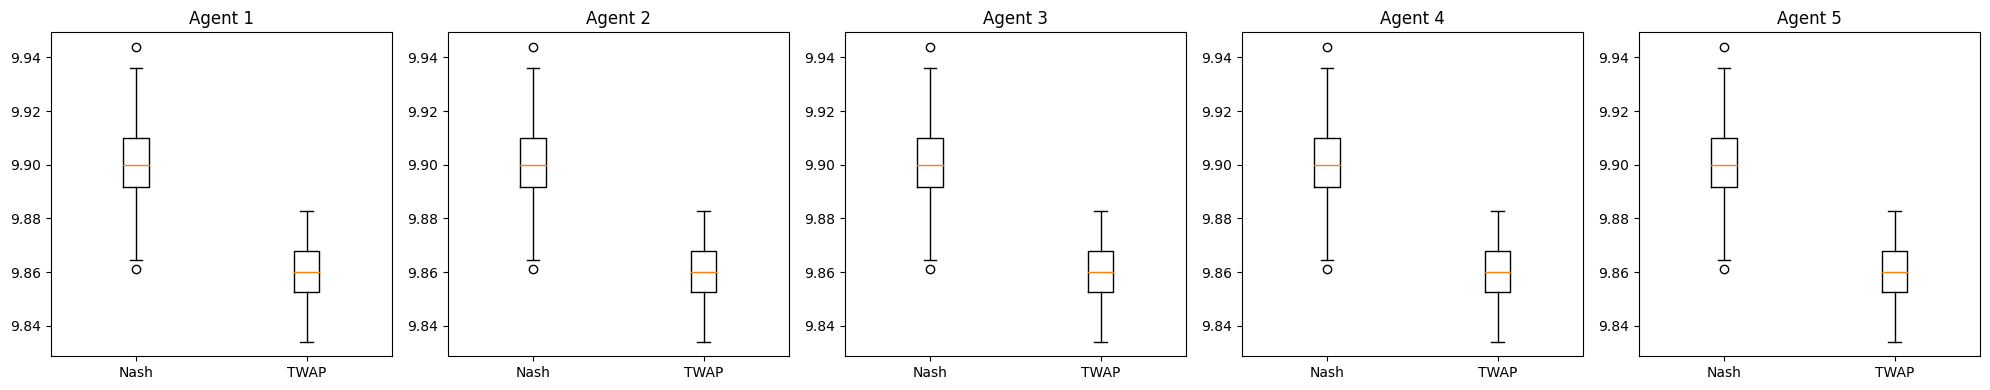

In [126]:
def run_nash(env, model, n=100):
    rewards = []
    for _ in range(n):
        state = env.reset()
        ep = np.zeros(env.N)

        for _ in range(env.M):
            x = torch.FloatTensor(state).unsqueeze(0)
            inv = torch.FloatTensor(env.inv).unsqueeze(0)

            with torch.no_grad():
                action = model.nash_action(x, inv).numpy()[0]

            state, r, _ = env.step(action)
            ep += r

        rewards.append(ep)

    return np.array(rewards)


def run_twap(env, n=100):
    rewards = []
    for _ in range(n):
        state = env.reset()
        rate = env.inv0[0] / env.T
        ep = np.zeros(env.N)

        for _ in range(env.M):
            action = np.full(env.N, -rate)
            state, r, _ = env.step(action)
            ep += r

        rewards.append(ep)

    return np.array(rewards)


nash_r = run_nash(env, model)
twap_r = run_twap(env)

print("NASH vs TWAP")
for i in range(env.N):
    print(
        f"Agent {i} | "
        f"Nash={nash_r[:,i].mean():+.4f} "
        f"TWAP={twap_r[:,i].mean():+.4f} "
        f"Δ={nash_r[:,i].mean()-twap_r[:,i].mean():+.4f}"
    )
    
fig, axes = plt.subplots(1, env.N, figsize=(4*env.N, 4))

for i in range(env.N):
    axes[i].boxplot([nash_r[:,i], twap_r[:,i]])
    axes[i].set_title(f"Agent {i+1}")
    axes[i].set_xticklabels(["Nash", "TWAP"])

plt.tight_layout()
plt.show()

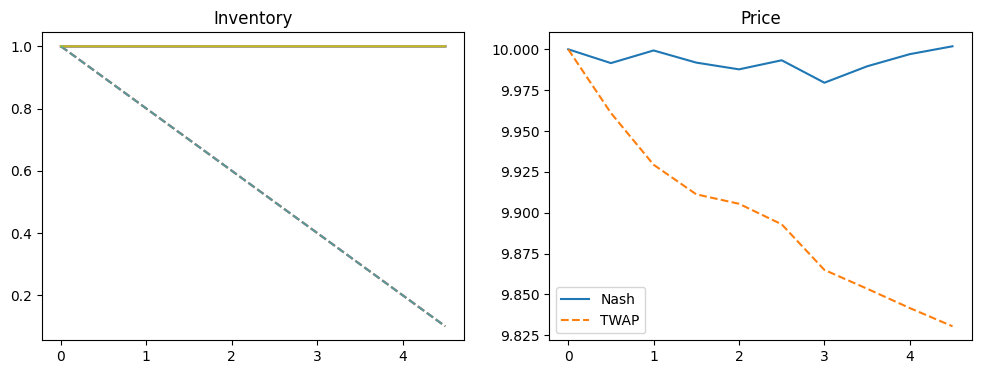

In [127]:
def rollout(env, policy):
    state = env.reset()
    invs, prices, t = [], [], []

    for _ in range(env.M):
        invs.append(env.inv.copy())
        prices.append(env.S)
        t.append(env.t)

        action = policy(state)
        state, _, _ = env.step(action)

    return np.array(t), np.array(invs), np.array(prices)


def nash_policy(state):
    x = torch.FloatTensor(state).unsqueeze(0)
    inv = torch.FloatTensor(env.inv).unsqueeze(0)
    with torch.no_grad():
        return model.nash_action(x, inv).numpy()[0]


def twap_policy(state):
    rate = env.inv0[0] / env.T
    return np.full(env.N, -rate)


t1, inv1, p1 = rollout(env, nash_policy)
t2, inv2, p2 = rollout(env, twap_policy)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

for i in range(env.N):
    ax[0].plot(t1, inv1[:,i], label=f"Nash {i}")
    ax[0].plot(t2, inv2[:,i], "--", alpha=0.5)

ax[1].plot(t1, p1, label="Nash")
ax[1].plot(t2, p2, "--", label="TWAP")

ax[0].set_title("Inventory")
ax[1].set_title("Price")

plt.legend()
plt.show()

In [128]:
import numpy as np
import torch

def run_episode(env, policy_fn):
    state = env.reset()
    rewards = np.zeros(env.N)

    for _ in range(env.M):
        action = policy_fn(state, env)
        state, r, done = env.step(action)
        rewards += r

    return rewards


# baseline Nash
def nash_policy(state, env):
    x = torch.FloatTensor(state).unsqueeze(0)
    inv = torch.FloatTensor(env.inv).unsqueeze(0)

    with torch.no_grad():
        return model.nash_action(x, inv).numpy()[0]


# deviation policy: 1 agent perturbe
def deviate_policy(agent_id, eps=0.5):
    def policy(state, env):
        base = nash_policy(state, env)
        noise = np.zeros(env.N)
        noise[agent_id] += eps
        return base + noise
    return policy


baseline_rewards = run_episode(env, nash_policy)

print("\n=== DEVIATION TEST ===")

# AVANT — 1 épisode, très bruité
baseline_rewards = run_episode(env, nash_policy)

# APRÈS — moyenner sur 200 épisodes
N_TEST = 200
baseline_all = np.array([run_episode(env, nash_policy) for _ in range(N_TEST)])
dev_all      = np.array([run_episode(env, deviate_policy(i)) for _ in range(N_TEST)])
print(f"baseline={baseline_all[:,i].mean():+.4f} ± {baseline_all[:,i].std():.4f}")
print(f"deviated={dev_all[:,i].mean():+.4f}   Δ={dev_all[:,i].mean()-baseline_all[:,i].mean():+.4f}")


=== DEVIATION TEST ===
baseline=+9.9005 ± 0.0200
deviated=+8.8776   Δ=-1.0229
